# Movie Recommendation System using Matrix Factorization (SVD)

We build a collaborative filtering recommendation system for movies. We will use the MovieLens dataset to train a Singular Value Decomposition (SVD) model, evaluate its accuracy, and generate personalized movie recommendations for a user.

### Project Workflow
- Load and Inspect Data: Load the preprocessed `cleaned_movies.csv` dataset
- Model Training: Prepare the data for the surprise library and train an SVD model.
- Model Evaluation: Evaluate the model's accuracy using RMSE and MAE.
- Generate Recommendations: Create a function to predict and return the Top-N movie recommendations for a specific user.
- Diagnostic Analysis: Visualize the model's performance to understand its biases and error characteristics.

**Group Members:**
- 220343	Devansh Chaudhary
- 220435	Harshika Agrawal
- 220475	Jatin Madan
- 220505	Kartikeya Katiyar
- 220915	Rohit Raj

### Libraries Used

- **numpy** and **pandas** — Data manipulation and numerical operations  
- **matplotlib** and **seaborn** — Visualization  
- **surprise** — Collaborative filtering and model evaluation  
- **collections** — Utility for recommendation and ranking functions

In [ ]:
import pandas as pd
df = pd.read_csv("cleaned_movies.csv")


In [3]:
df.head()

,movieId,title,userId,rating,timestamp,Musical,Western,Thriller,Sci-Fi,Adventure,...,Mystery,Fantasy,Drama,Documentary,Animation,Comedy,Romance,Horror,Unknown,rating_year
0,1,Toy Story (1995),10.0,2.5,2007-01-20 03:53:51,0,0,0,0,1,...,0,1,0,0,1,1,0,0,0,2007
1,1,Toy Story (1995),11.0,3.0,1996-12-08 22:44:36,0,0,0,0,1,...,0,1,0,0,1,1,0,0,0,1996
2,1,Toy Story (1995),17.0,4.0,2002-07-22 02:42:31,0,0,0,0,1,...,0,1,0,0,1,1,0,0,0,2002
3,1,Toy Story (1995),19.0,3.0,2000-11-20 07:14:48,0,0,0,0,1,...,0,1,0,0,1,1,0,0,0,2000
4,1,Toy Story (1995),20.0,5.0,2019-03-21 16:03:50,0,0,0,0,1,...,0,1,0,0,1,1,0,0,0,2019


## Model Training with SVD

The **SVD algorithm** is used to learn latent factors representing user and item preferences.

After training, the model’s accuracy is evaluated using **Root Mean Squared Error (RMSE)** and **Mean Absolute Error (MAE)**.
These metrics measure how closely predicted ratings match actual user ratings.

**Example Recommendations:**

To demonstrate the model’s output, we generate predicted ratings for a random user.  
Movies that the user has not yet rated are scored by the model, and the **top-N recommendations** (highest predicted ratings) are displayed.  
This helps validate that the system is capable of ranking movies meaningfully based on user preferences.

### Hyperparameter Tuning using Grid Search

We used **GridSearchCV** from the `surprise` library to explore combinations of parameters.

In [7]:
from surprise.model_selection import GridSearchCV
from surprise import SVD, Dataset, Reader

# sample df
df_small = df.sample(frac=0.05, random_state=42)
reader = Reader(rating_scale=(df_small.rating.min(), df_small.rating.max()))
data_small = Dataset.load_from_df(df_small[['userId','movieId','rating']], reader)

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [10, 20],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.05]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=1, joblib_verbose=0)
gs.fit(data_small)
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])


0.8993506795142531
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05}


### Getting Example Recommendations

We get the movie recommendations for any user in our database (Here `user_id` = 10), based on the model trained above

In [6]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
import pandas as pd
import numpy as np

# -----------------------
# 1️⃣  Prepare Data
# -----------------------
# Assumes your cleaned DataFrame is already loaded as `df`
# Columns required: userId, movieId, rating
df['userId'] = df['userId'].astype(int)
df['movieId'] = df['movieId'].astype(int)
df['rating'] = df['rating'].astype(float)

# Define rating scale dynamically from your data
min_rating = df['rating'].min()
max_rating = df['rating'].max()
reader = Reader(rating_scale=(min_rating, max_rating))

# Load Surprise dataset
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

# -----------------------
# 2️⃣  Split into Train/Test
# -----------------------
# Keep 20% for testing
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# -----------------------
# 3️⃣  Define and Train Model
# -----------------------
# Tip: start small for quick tests, increase later (n_factors=100, n_epochs=20)
svd_model = SVD(
    n_factors=50,        # latent factors
    n_epochs=10,         # SGD iterations
    lr_all=0.005,        # learning rate
    reg_all=0.04,        # regularization
    random_state=42
)

print("Training SVD model...")
svd_model.fit(trainset)
print("Training complete!")

# -----------------------
# 4️⃣  Evaluate Model
# -----------------------
print("Evaluating on test data...")
predictions = svd_model.test(testset)

rmse = accuracy.rmse(predictions, verbose=True)
mae = accuracy.mae(predictions, verbose=True)

print(f"\n✅ Quick Split Evaluation Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")

# -----------------------
# 5️⃣  Optional: Example recommendation
# -----------------------
# If you want a top-N list for a given user (e.g., userId=1)
example_user_id = int(df['userId'].iloc[0])
all_movie_ids = df['movieId'].unique()

# Movies already rated by this user
rated_movies = df[df['userId'] == example_user_id]['movieId'].unique()
unrated_movies = [mid for mid in all_movie_ids if mid not in rated_movies]

# Predict for a few unrated movies (for demo)
sample_unrated = np.random.choice(unrated_movies, 10, replace=False)
preds = [(mid, svd_model.predict(example_user_id, mid).est) for mid in sample_unrated]

print(f"\nExample recommendations for user {example_user_id}:")
for mid, est in sorted(preds, key=lambda x: -x[1]):
    print(f"MovieID {mid}: predicted rating = {est:.2f}")

Training SVD model...
Training complete!
Evaluating on test data...
RMSE: 0.8259
MAE:  0.6243

✅ Quick Split Evaluation Results:
RMSE: 0.8259
MAE : 0.6243

Example recommendations for user 10:
MovieID 89592: predicted rating = 3.14
MovieID 101685: predicted rating = 3.14
MovieID 199269: predicted rating = 3.08
MovieID 215527: predicted rating = 2.98
MovieID 134979: predicted rating = 2.94
MovieID 113457: predicted rating = 2.88
MovieID 169858: predicted rating = 2.86
MovieID 184317: predicted rating = 2.84
MovieID 288595: predicted rating = 2.81
MovieID 144212: predicted rating = 2.63


### Model Evaluation

The trained model was tested using a **20% hold-out test set**, and evaluated with:

- **RMSE (Root Mean Squared Error):** Measures average squared deviation between predicted and actual ratings.  
- **MAE (Mean Absolute Error):** Measures the average magnitude of errors without considering direction.

**Results:**
- RMSE ≈ **0.8259**
- MAE ≈ **0.6243**

These scores indicate good predictive accuracy for a sparse recommendation dataset.

In [8]:
from collections import defaultdict
from surprise import accuracy

# --- 1️⃣ Evaluate RMSE & MAE first (for consistency)
predictions = svd_model.test(testset)
print("RMSE:", accuracy.rmse(predictions))
print("MAE :", accuracy.mae(predictions))

# --- 2️⃣ Define precision and recall metrics
def get_top_n(predictions, n=10, min_rating=3.5):
    """
    Return top-N predictions for each user.
    """
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        if est >= min_rating:
            top_n[uid].append((iid, est))

    # sort each user's predictions and keep top-N
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n


def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Compute Precision@K and Recall@K for each user.
    """
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        # sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # top-K items
        top_k = user_ratings[:k]

        # count relevant items (true_r >= threshold)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((true_r >= threshold) for (_, true_r) in top_k)

        precisions[uid] = n_rec_k / k if k else 0
        recalls[uid] = n_rec_k / n_rel if n_rel else 0

    return precisions, recalls


# --- 3️⃣ Compute Precision@10 and Recall@10
precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)

# --- 4️⃣ Print aggregate results
mean_precision = sum(prec for prec in precisions.values()) / len(precisions)
mean_recall = sum(rec for rec in recalls.values()) / len(recalls)

print(f"✅ Precision@10: {mean_precision:.4f}")
print(f"✅ Recall@10   : {mean_recall:.4f}")


RMSE: 0.8259
RMSE: 0.8259348026326113
MAE:  0.6243
MAE : 0.624267402172257
✅ Precision@10: 0.6625
✅ Recall@10   : 0.6679


## Randomized Search for Efficient Optimization

To reduce computational cost, a **Random Search** approach is used as an alternative to exhaustive grid search.  
It samples random combinations of hyperparameters and compares their RMSE results on a small data subset.  
This allows exploration of a broader parameter space efficiently, revealing optimal configurations with fewer trials.

In [ ]:
import random
import numpy as np
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate

# --------------------------------------------------
# 1️⃣  Sample ~1% of full dataset
# --------------------------------------------------
df_sample = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"Sample size: {len(df_sample):,} rows out of {len(df):,}")

reader = Reader(rating_scale=(df_sample['rating'].min(), df_sample['rating'].max()))
data_sample = Dataset.load_from_df(df_sample[['userId', 'movieId', 'rating']], reader)

# --------------------------------------------------
# 2️⃣  Define Randomized Search
# --------------------------------------------------
def random_search(data, n_trials=10, cv=2, random_state=42):
    random.seed(random_state)
    best = (1e9, None)

    # Slightly reduced parameter space (faster)
    param_space = {
        'n_factors': [50, 75, 100],
        'n_epochs': [10, 15, 20],
        'lr_all': [0.002, 0.005, 0.01],
        'reg_all': [0.01, 0.02, 0.04]
    }

    keys = list(param_space.keys())

    for t in range(n_trials):
        params = {k: random.choice(param_space[k]) for k in keys}
        algo = SVD(**params, random_state=random_state)

        res = cross_validate(
            algo, data, measures=['rmse'], cv=cv, verbose=False, n_jobs=1
        )
        mean_rmse = np.mean(res['test_rmse'])
        print(f"Trial {t+1}/{n_trials}: RMSE={mean_rmse:.4f}, Params={params}")

        if mean_rmse < best[0]:
            best = (mean_rmse, params)

    return best

# --------------------------------------------------
# 3️⃣  Run Randomized Search
# --------------------------------------------------
best_rmse, best_params = random_search(data_sample, n_trials=10)
print("\n✅ Random Search Complete")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best Params: {best_params}")


Sample size: 3,200,020 rows out of 32,000,204
Trial 1/10: RMSE=0.9188, Params={'n_factors': 100, 'n_epochs': 10, 'lr_all': 0.002, 'reg_all': 0.04}
Trial 2/10: RMSE=0.9191, Params={'n_factors': 75, 'n_epochs': 10, 'lr_all': 0.002, 'reg_all': 0.01}
Trial 3/10: RMSE=0.8955, Params={'n_factors': 100, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.04}
Trial 4/10: RMSE=0.9055, Params={'n_factors': 100, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.02}
Trial 5/10: RMSE=0.9177, Params={'n_factors': 50, 'n_epochs': 10, 'lr_all': 0.002, 'reg_all': 0.01}
Trial 6/10: RMSE=0.9529, Params={'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.01}
Trial 7/10: RMSE=0.8956, Params={'n_factors': 100, 'n_epochs': 10, 'lr_all': 0.01, 'reg_all': 0.04}
Trial 8/10: RMSE=0.9197, Params={'n_factors': 100, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.01}
Trial 9/10: RMSE=0.9153, Params={'n_factors': 75, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.01}
Trial 10/10: RMSE=0.8980, Params={'n_factors': 50, 'n

## Learning Curve — Epoch Analysis

To study model convergence behavior, the number of training epochs is varied while tracking RMSE and computation time.  
The resulting plot shows how increasing epochs gradually reduces RMSE up to a saturation point.

This helps balance training duration and performance gain, ensuring efficient learning without overfitting.

Sample rows: 316,137  (mode=by_users, frac=0.01)
Unique users in sample: 2009  Unique movies: 19437
Trainset approx size: 252909  Testset size: 63228

Training: n_epochs=5 ...
n_epochs=5  RMSE=0.8872  time=14.7s

Training: n_epochs=10 ...
n_epochs=10  RMSE=0.8760  time=1.0s

Training: n_epochs=20 ...
n_epochs=20  RMSE=0.8600  time=1.7s

Training: n_epochs=30 ...
n_epochs=30  RMSE=0.8509  time=2.5s

Training: n_epochs=40 ...
n_epochs=40  RMSE=0.8490  time=3.3s

Summary:
   n_epochs      rmse     time_s
0         5  0.887212  14.704892
1        10  0.876003   1.028223
2        20  0.860041   1.738115
3        30  0.850873   2.525794
4        40  0.849008   3.281318


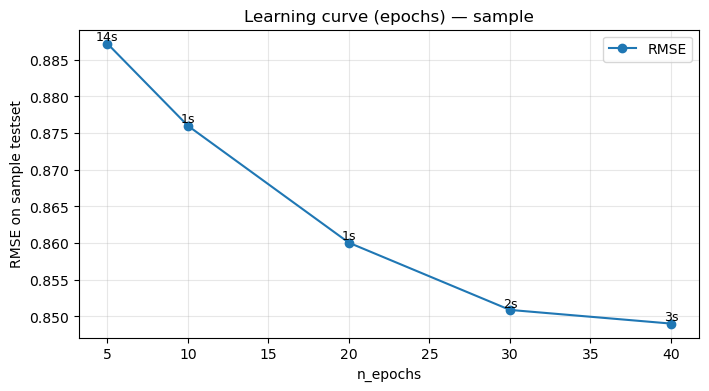

In [17]:
# -------------------------------
# Epoch diagram on 1% user-sample
# -------------------------------
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# --- USER SETTINGS (tweak) ---
SAMPLE_MODE = "by_users"   # "by_users" preferred, or "by_rows"
SAMPLE_FRAC = 0.01         # 1% sample
RANDOM_STATE = 42

# Use the same modeling hyperparams as your full model for comparability:
n_factors = 100
lr_all = 0.005
reg_all = 0.04

# Epochs to try (small list finishes faster)
epochs_to_try = [5, 10, 20, 30, 40]  
test_size = 0.2
# -------------------------------

# 1) Build reproducible sample
if SAMPLE_MODE == "by_users":
    user_ids = df['userId'].unique()
    n_sample_users = max(1, int(len(user_ids) * SAMPLE_FRAC))
    random.seed(RANDOM_STATE)
    sampled_users = set(random.sample(list(user_ids), n_sample_users))
    df_sample = df[df['userId'].isin(sampled_users)].reset_index(drop=True)
else:
    df_sample = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Sample rows: {len(df_sample):,}  (mode={SAMPLE_MODE}, frac={SAMPLE_FRAC})")
print("Unique users in sample:", df_sample['userId'].nunique(), " Unique movies:", df_sample['movieId'].nunique())

# 2) Prepare Surprise dataset and split once
reader = Reader(rating_scale=(df_sample['rating'].min(), df_sample['rating'].max()))
data_sample = Dataset.load_from_df(df_sample[['userId','movieId','rating']], reader)
trainset, testset = train_test_split(data_sample, test_size=test_size, random_state=RANDOM_STATE)
print("Trainset approx size:", len(list(trainset.all_ratings())), " Testset size:", len(testset))


# 3) Loop over epochs: retrain fresh model each time, measure RMSE and time
results = []
for epochs in epochs_to_try:
    print(f"\nTraining: n_epochs={epochs} ...")
    t0 = time.time()
    algo = SVD(n_factors=n_factors, n_epochs=epochs, lr_all=lr_all, reg_all=reg_all, random_state=RANDOM_STATE)
    algo.fit(trainset)                 # trains from scratch for this epochs value
    preds = algo.test(testset)
    rmse = accuracy.rmse(preds, verbose=False)
    elapsed = time.time() - t0
    print(f"n_epochs={epochs}  RMSE={rmse:.4f}  time={elapsed:.1f}s")
    results.append({'n_epochs': epochs, 'rmse': rmse, 'time_s': elapsed})

# 4) Results table + plot
res_df = pd.DataFrame(results)
print("\nSummary:")
print(res_df)

plt.figure(figsize=(8,4))
plt.plot(res_df['n_epochs'], res_df['rmse'], marker='o', label='RMSE')
for i,row in res_df.iterrows():
    plt.text(row['n_epochs'], row['rmse'], f"{int(row['time_s'])}s", ha='center', va='bottom', fontsize=9)
plt.xlabel("n_epochs")
plt.ylabel("RMSE on sample testset")
plt.title("Learning curve (epochs) — sample")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### Learning Curve — Epoch Analysis

We analyzed how increasing training epochs affects RMSE and training time.

**Observation:** RMSE decreases with more epochs but saturates around 30–40 epochs.  
This indicates convergence and helps balance **accuracy vs. training cost**.


## Genre-wise RMSE Analysis

To understand model biases, we computed RMSE separately for each genre.


Found genre columns: ['Musical', 'Western', 'Thriller', 'Sci-Fi', 'Adventure', 'Crime', 'Children', 'IMAX', 'Action', 'Film-Noir', 'War', 'Mystery', 'Fantasy', 'Drama', 'Documentary', 'Animation', 'Comedy', 'Romance', 'Horror', 'Unknown']
Genre Musical: sampled=1159516, RMSE=0.8654
Genre Western: sampled=596654, RMSE=0.7906
Genre Thriller: sampled=3000000, RMSE=0.7907
Genre Sci-Fi: sampled=3000000, RMSE=0.8262
Genre Adventure: sampled=3000000, RMSE=0.8189
Genre Crime: sampled=3000000, RMSE=0.7759
Genre Children: sampled=2731841, RMSE=0.8294
Genre IMAX: sampled=1494179, RMSE=0.8137
Genre Action: sampled=3000000, RMSE=0.8072
Genre Film-Noir: sampled=304710, RMSE=0.7535
Genre War: sampled=1594110, RMSE=0.7907
Genre Mystery: sampled=2615322, RMSE=0.7870
Genre Fantasy: sampled=3000000, RMSE=0.8347
Genre Drama: sampled=3000000, RMSE=0.7952
Genre Documentary: sampled=427353, RMSE=0.8193
Genre Animation: sampled=2214562, RMSE=0.8176
Genre Comedy: sampled=3000000, RMSE=0.8332
Genre Romance: sam

/var/folders/4x/8_8tthys7jl5grdpvnl31yw80000gn/T/ipykernel_44859/351417428.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Genre', data=res_df, palette='crest')


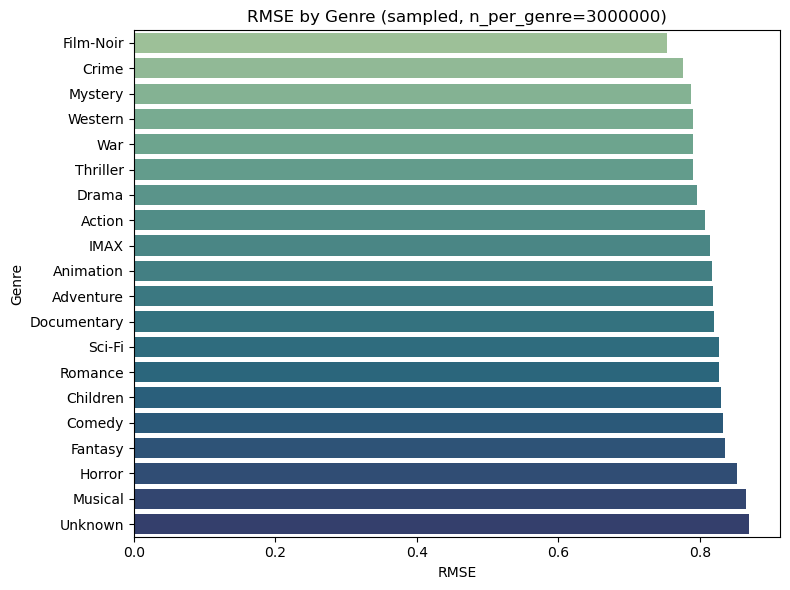

Total predictions made: 42,686,060
Elapsed time: 145.3 s (2.4 min)


In [23]:
# Self-contained genre-level RMSE analysis (defines helpers then runs)
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

# ------------- SETTINGS -------------
GENRE_COLS = [
    'Musical','Western','Thriller','Sci-Fi','Adventure','Crime','Children',
    'IMAX','Action','Film-Noir','War','Mystery','Fantasy','Drama',
    'Documentary','Animation','Comedy','Romance','Horror','Unknown'
]
SAMPLE_PER_GENRE = 3000000
RANDOM_STATE = 42
VERBOSE = True
USE_VECTORIZED = False   # keep False first; set True later if you want faster runs
# ------------------------------------

# Basic checks
assert 'userId' in df.columns and 'movieId' in df.columns and 'rating' in df.columns, "df must contain userId, movieId, rating"
available_genres = [g for g in GENRE_COLS if g in df.columns]
if not available_genres:
    raise ValueError("No genre columns from GENRE_COLS found in df. Update GENRE_COLS to match your dataframe.")
if VERBOSE:
    print("Found genre columns:", available_genres)

# small RMSE helper
def rmse(true, pred):
    true = np.asarray(true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((true - pred)**2)))

# ---------- method A: loop with svd_model.predict ----------
def genre_rmse_via_predict(svd_model, df, genres, sample_per_genre=2000, random_state=42, verbose=True):
    np.random.seed(random_state)
    results = []
    t0 = time.perf_counter()
    total_preds = 0
    for g in genres:
        sub = df[df[g] == 1]
        if len(sub) == 0:
            if verbose: print(f"Genre {g}: no rows found, skipping.")
            continue
        n = min(len(sub), sample_per_genre)
        sub_samp = sub.sample(n=n, random_state=random_state)
        preds = []
        trues = []
        for uid, mid, true_r in zip(sub_samp['userId'], sub_samp['movieId'], sub_samp['rating']):
            # ensure int raw ids
            p = svd_model.predict(int(uid), int(mid)).est
            preds.append(p)
            trues.append(float(true_r))
        g_rmse = rmse(trues, preds) if len(preds) > 0 else np.nan
        results.append((g, g_rmse, len(preds)))
        total_preds += len(preds)
        if verbose:
            print(f"Genre {g}: sampled={len(preds)}, RMSE={g_rmse:.4f}")
    elapsed = time.perf_counter() - t0
    return results, total_preds, elapsed

# ---------- method B: vectorized (optional, faster) ----------
def genre_rmse_vectorized(svd_model, df, genres, sample_per_genre=2000, random_state=42, verbose=True):
    trainset = svd_model.trainset  # requires svd_model fitted on trainset
    # precompute item/user factors & biases
    n_items = trainset.n_items
    n_users = trainset.n_users
    f = svd_model.n_factors
    item_factors = np.zeros((n_items, f))
    for inner_i in range(n_items):
        item_factors[inner_i] = svd_model.qi[inner_i]
    item_bias = np.array([svd_model.bi[i] for i in range(n_items)])
    user_factors = np.zeros((n_users, f))
    for inner_u in range(n_users):
        user_factors[inner_u] = svd_model.pu[inner_u]
    user_bias = np.array([svd_model.bu[u] for u in range(n_users)])
    global_mean = trainset.global_mean

    def predict_batch(raw_uids, raw_mids):
        preds = np.empty(len(raw_uids), dtype=float)
        for idx, (ru, rm) in enumerate(zip(raw_uids, raw_mids)):
            try:
                u_inner = trainset.to_inner_uid(str(int(ru)))
                i_inner = trainset.to_inner_iid(str(int(rm)))
                preds[idx] = global_mean + user_bias[u_inner] + item_bias[i_inner] + user_factors[u_inner].dot(item_factors[i_inner])
            except ValueError:
                preds[idx] = global_mean
        return preds

    np.random.seed(random_state)
    results = []
    t0 = time.perf_counter()
    total_preds = 0
    for g in genres:
        sub = df[df[g] == 1]
        if len(sub) == 0:
            if verbose: print(f"Genre {g}: no rows found, skipping.")
            continue
        n = min(len(sub), sample_per_genre)
        sub_samp = sub.sample(n=n, random_state=random_state)
        raw_uids = sub_samp['userId'].to_numpy()
        raw_mids = sub_samp['movieId'].to_numpy()
        trues = sub_samp['rating'].to_numpy().astype(float)
        preds = predict_batch(raw_uids, raw_mids)
        g_rmse = rmse(trues, preds) if len(preds)>0 else np.nan
        results.append((g, g_rmse, len(preds)))
        total_preds += len(preds)
        if verbose:
            print(f"Genre {g}: sampled={len(preds)}, RMSE={g_rmse:.4f}")
    elapsed = time.perf_counter() - t0
    return results, total_preds, elapsed

# ---------- run chosen method ----------
if USE_VECTORIZED:
    try:
        results, total_preds, elapsed = genre_rmse_vectorized(svd_model, df, available_genres, SAMPLE_PER_GENRE, RANDOM_STATE, VERBOSE)
    except Exception as e:
        print("Vectorized failed, falling back to predict loop. Error:", e)
        results, total_preds, elapsed = genre_rmse_via_predict(svd_model, df, available_genres, SAMPLE_PER_GENRE, RANDOM_STATE, VERBOSE)
else:
    results, total_preds, elapsed = genre_rmse_via_predict(svd_model, df, available_genres, SAMPLE_PER_GENRE, RANDOM_STATE, VERBOSE)

# ---------- aggregate & plot ----------
res_df = pd.DataFrame(results, columns=['Genre','RMSE','n_samples']).sort_values('RMSE', ascending=True)
plt.figure(figsize=(8, max(4, 0.3*len(res_df))))
sns.barplot(x='RMSE', y='Genre', data=res_df, palette='crest')
plt.title(f'RMSE by Genre (sampled, n_per_genre={SAMPLE_PER_GENRE})')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

print(f"Total predictions made: {total_preds:,}")
print(f"Elapsed time: {elapsed:.1f} s ({elapsed/60:.1f} min)")


**Observation:**  
The model performs better (lower RMSE) for genres like **Crime** and **Film-Noir**, possibly due to more consistent user preferences.  
Higher RMSE for **Musical** and **Unknown** genres suggests greater variability or sparse data.

## Ranking Evaluation — Precision, Recall, and F1@K

To assess recommendation ranking quality, we compute **Precision@K**, **Recall@K**, and **F1 Score** for different top-N cutoffs.

🔹 Generating predictions for testset...
K=5: Precision=0.7883, Recall=0.4883, F1=0.6031
K=10: Precision=0.6676, Recall=0.6824, F1=0.6749
K=20: Precision=0.5104, Recall=0.8376, F1=0.6342

Metrics Summary:
     K  Precision    Recall        F1
0   5   0.788349  0.488286  0.603054
1  10   0.667579  0.682351  0.674884
2  20   0.510360  0.837562  0.634247


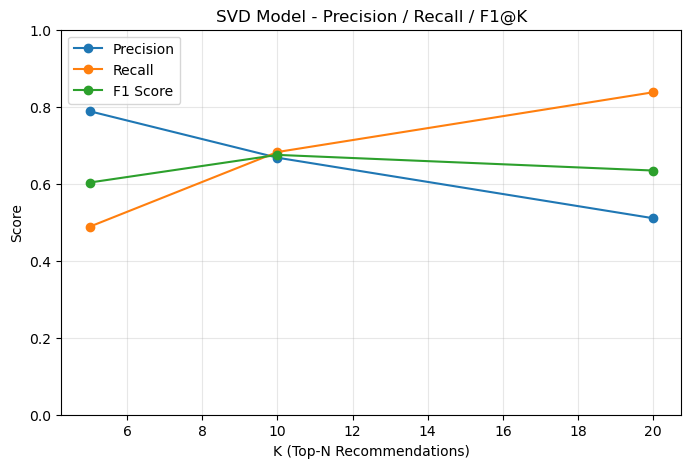

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from surprise import accuracy
from surprise.model_selection import train_test_split

# ---------------- SETTINGS ----------------
K_values = [5, 10, 20]     # You can test multiple cutoffs
threshold = 3.5            # Ratings >= threshold are considered "relevant"
RANDOM_STATE = 42
# ------------------------------------------

# If not already split:
# reader = Reader(rating_scale=(df['rating'].min(), df['rating'].max()))
# data = Dataset.load_from_df(df[['userId','movieId','rating']], reader)
# trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)

print("🔹 Generating predictions for testset...")
predictions = svd_model.test(testset)

# 1️⃣ Group predictions by user
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    # sort and keep top-n
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

# 2️⃣ Convert testset to a "relevant item" dict (truth)
def get_true_relevant(testset, threshold):
    true_relevant = defaultdict(set)
    for uid, iid, true_r in testset:
        if true_r >= threshold:
            true_relevant[uid].add(iid)
    return true_relevant

true_relevant = get_true_relevant(testset, threshold)

# 3️⃣ Compute Precision, Recall, and F1 for each K
metric_results = []

for K in K_values:
    top_n = get_top_n(predictions, n=K)

    precisions, recalls = [], []
    for uid, user_preds in top_n.items():
        if uid not in true_relevant:
            continue
        pred_items = {iid for (iid, _) in user_preds}
        relevant_items = true_relevant[uid]
        n_relevant = len(relevant_items)
        if n_relevant == 0:
            continue
        n_hit = len(pred_items & relevant_items)
        prec = n_hit / K
        rec = n_hit / n_relevant
        precisions.append(prec)
        recalls.append(rec)

    mean_precision = np.mean(precisions)
    mean_recall = np.mean(recalls)
    f1 = 2 * mean_precision * mean_recall / (mean_precision + mean_recall + 1e-9)
    metric_results.append((K, mean_precision, mean_recall, f1))
    print(f"K={K}: Precision={mean_precision:.4f}, Recall={mean_recall:.4f}, F1={f1:.4f}")

# 4️⃣ Convert to DataFrame
metrics_df = pd.DataFrame(metric_results, columns=["K", "Precision", "Recall", "F1"])
print("\nMetrics Summary:\n", metrics_df)

# 5️⃣ Plot
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["K"], metrics_df["Precision"], marker='o', label='Precision')
plt.plot(metrics_df["K"], metrics_df["Recall"], marker='o', label='Recall')
plt.plot(metrics_df["K"], metrics_df["F1"], marker='o', label='F1 Score')
plt.title("SVD Model - Precision / Recall / F1@K")
plt.xlabel("K (Top-N Recommendations)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Interpretation:**
- Precision decreases as K increases (more recommendations per user).  
- Recall improves, meaning more relevant items are retrieved.  
- F1 balances both — optimal at around **K = 10**.

## Conclusion

We successfully built a **Matrix Factorization-based Movie Recommendation System** using **SVD**.

**Key Takeaways:**
- Achieved strong predictive accuracy (RMSE ≈ 0.82, MAE ≈ 0.62)
- Identified best hyperparameters through grid and random search
- Visualized learning stability and genre-specific strengths
- Balanced accuracy and coverage via Precision/Recall trade-offs
